Pregunta:
Teniendo los datos del primer parcial,segundo parcial y la Firma con el nuevo reglamento, estimar la nota final en la materia Mecanica de Solidos.

In [45]:
import pandas as pd
import numpy as np
import re
import glob

dl = glob.glob('/content/drive/MyDrive/IA-Dataset/nuevo/*.xlsx')
#en la carpeta nuevo van los archivos excel para el concatenamiento
#son los archivos de la nueva malla.
df_nuevo = pd.concat([pd.read_excel(file) for file in dl],ignore_index=True)
'''
df = pd.read_excel('/content/drive/MyDrive/IA-Dataset/viejo/rendimiento_aдo_2024_ciclo_1_anon.xlsx')

df['Primer.Par']= (df['Primer.Par']/24)*100 #Normalizar 1er P
df['Segundo.Par']=(df['Segundo.Par']/36)*100 #Normalizar 2er P
df['AOT'] = (df['AOT']/10)*100 #Normalizar AOT
df['Firma'] = (df['Firma']/70)*100
## Extraccion de notas
df['Nota.Final']=df['parsed_value'] = (
    df['Nota.Final']
    .str.findall(r'-(\d+)')
    .apply(lambda x: max(map(int, x)) if isinstance(x, list) and len(x) > 0 else np.nan)
)'''
#Corregir la nota final tomando el mayor valor
df_nuevo['Nota.Final']=df_nuevo['parsed_value'] = (
    df_nuevo['Nota.Final']
    .str.findall(r'-(\d+)')
    .apply(lambda x: max(map(int, x)) if isinstance(x, list) and len(x) > 0 else np.nan)
)
df_nuevo.drop(['parsed_value'], axis=1, inplace=True)

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1465/2960677342.py:20: SyntaxWarning: invalid escape sequence '\d'
  .str.findall(r'-(\d+)')


In [46]:
# Mostrar información malla nueva completa
print("\n" + "=" * 70)
print("INFORMACIÓN DEL DATASET MALLA NUEVA")
print("=" * 70)
print(f"\nRegistros totales: {len(df_nuevo):,}")
print(f"Estudiantes únicos: {df_nuevo['ALUMNO_ID'].nunique():,}")
print(f"Asignaturas: {df_nuevo['Asignatura'].nunique()}")
print(f"Carreras: {df_nuevo['Cod.Car.Sec'].nunique()}")
print(f"\nDistribución de notas:")
print(df_nuevo['Nota.Final'].value_counts())
print(f"Promedio de notas finales {(df_nuevo['Nota.Final']).mean()}")


INFORMACIÓN DEL DATASET MALLA NUEVA

Registros totales: 64,295
Estudiantes únicos: 4,759
Asignaturas: 326
Carreras: 27

Distribución de notas:
Nota.Final
4.0    12586
2.0     9311
5.0     8992
3.0     8200
1.0     3631
Name: count, dtype: int64
Promedio de notas finales 3.3276451310861423


In [47]:
print("##################################")
print(df_nuevo.columns)
##Luego de percatarme de que Mecsol no se abrio en el periodo de la malla vieja
## procedi a solo utilizar los datos concatenados de la malla nueva.

##################################
Index(['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso',
       'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado',
       'Anho.Firma', 'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.',
       'Lab.', 'Proy.', 'Pond.PP', 'Pond.SP', 'Pond.TPLab', 'Pond.Lab',
       'Pond.Proy', 'Asis', 'Requisito', 'Firma', 'Primer.Rec', 'Segundo.Rec',
       'Nota.Final', 'FirmaCalculada'],
      dtype='object')


Se realizara el filtrado y acondicionamiento de los datos a fin de separar las variables objetivo del resto del dataset.

In [48]:
# =============================================================================
# FILTRAR POR ASIGNATURA
# =============================================================================

print("\n" + "=" * 70)
print("FILTRANDO POR ASIGNATURA")
print("=" * 70)

# Buscar Mecanica de Solidos
if 'Asignatura' in df_nuevo.columns:
    patrones = ['MECANICA DE SOLIDOS']
    mask2 = df_nuevo['Asignatura'].str.upper().str.contains('|'.join(patrones), na=False)
    df_filtrado2 = df_nuevo[mask2].copy()
    print(f"✅ Registros de MecSol: {len(df_filtrado2):,}")
else:
    df_filtrado2 = df_nuevo.copy()
    print(f"✅ Usando todos los registros: {len(df_filtrado2):,}")

if len(df_filtrado2) == 0:
    print("⚠️ No se encontraron registros. Usando todos los datos.")
    df_filtrado2 = df_nuevo.copy()

# Mostrar distribución
if 'Nota.Final' in df_filtrado2.columns:
    print(f"\nDistribución de notas:")
    print(df_filtrado2['Nota.Final'].value_counts())
    print(f"Promedio de notas finales {(df_filtrado2['Nota.Final']).mean()}")




FILTRANDO POR ASIGNATURA
✅ Registros de MecSol: 234

Distribución de notas:
Nota.Final
2.0    48
3.0    34
4.0    34
5.0    16
1.0    16
Name: count, dtype: int64
Promedio de notas finales 2.9054054054054053


=== Estadísticas Descriptivas ===
          Cod.Asign  Cod.Curso  Convocatoria         Anho  Semestre  \
count    234.000000      234.0         234.0   234.000000     234.0   
mean   15841.094017        5.0           1.0  2024.487179       2.0   
std     4133.889071        0.0           0.0     0.500907       0.0   
min    13608.000000        5.0           1.0  2024.000000       2.0   
25%    13711.000000        5.0           1.0  2024.000000       2.0   
50%    13711.000000        5.0           1.0  2024.000000       2.0   
75%    13711.000000        5.0           1.0  2025.000000       2.0   
max    23754.000000        5.0           1.0  2025.000000       2.0   

          Doc.Firma   Anho.Firma  Primer.Par  Segundo.Par  Tercer.Par  ...  \
count    234.000000   234.000000  234.000000   234.000000       234.0  ...   
mean   25206.487179  1349.512821   35.888889    46.384615         0.0  ...   
std    17871.052327   956.295325   22.253235    32.019534         0.0  ...   
min        0.0

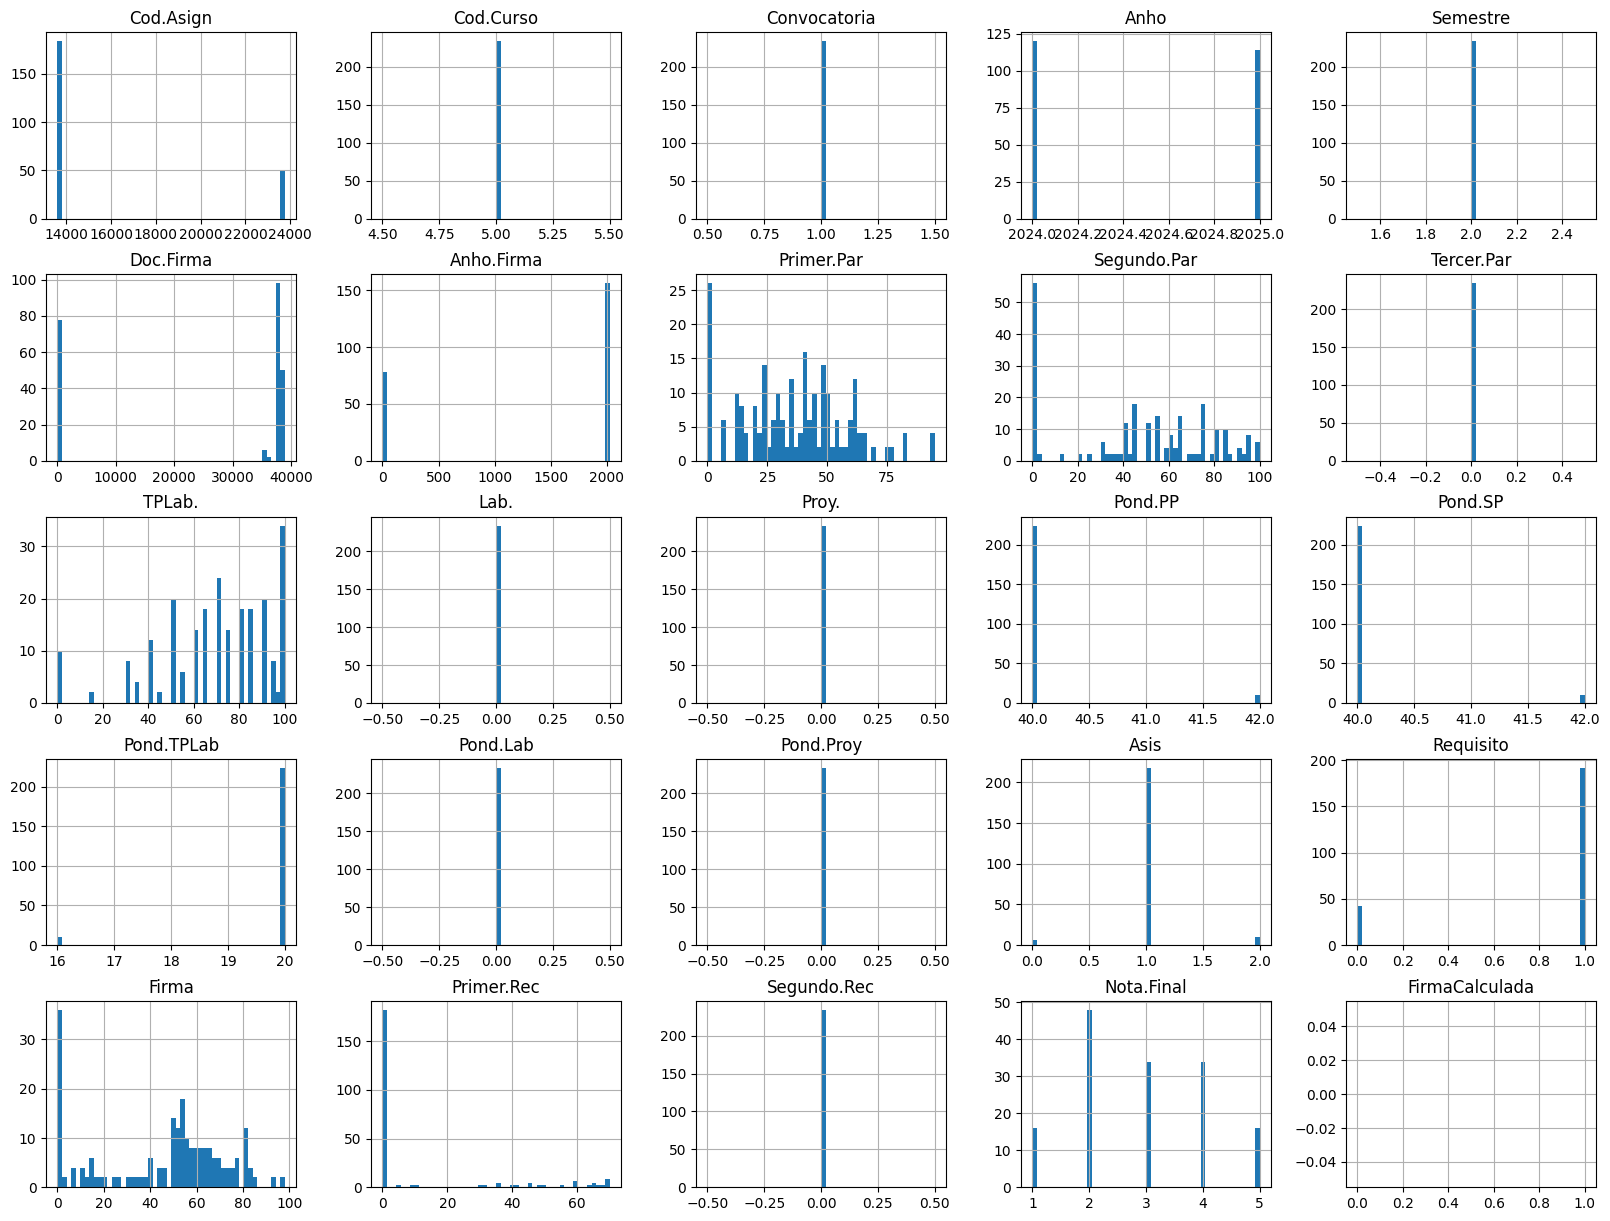

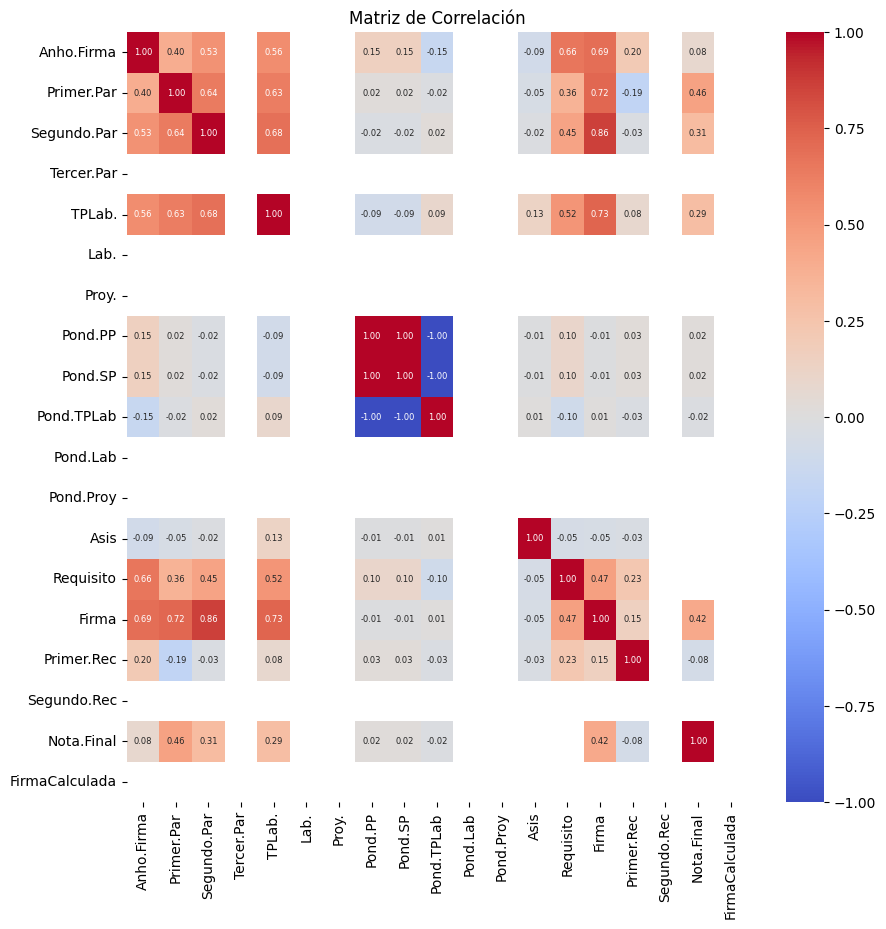

In [49]:
# Mostrar estadísticas descriptivas
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Estadísticas Descriptivas ===")
print(df_filtrado2.describe())


print("\n=== Información del Dataset ===")
df_filtrado2.info()

#Verificar valores nulos
print("\n=== Valores Nulos ===")
df_filtrado2.isnull().sum()

##histograma
df_filtrado2.hist(bins=50, figsize=(20,15))
#Matriz de correlacion
plt.figure(figsize=(10, 10))
sns.heatmap( df_filtrado2.drop(['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso',
       'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado'],axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f",annot_kws={"size": 6} )
plt.title('Matriz de Correlación')
plt.show()

In [50]:
df_filtrado2.head()

,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,...,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,FirmaCalculada
25317,FIUNA_ALUMNO_005475,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,16,0,0,1,1,72.0,70,0,5.0,NaN
25318,FIUNA_ALUMNO_008512,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,16,0,0,1,1,72.0,70,0,5.0,NaN
25319,FIUNA_ALUMNO_009719,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38604,S,...,16,0,0,1,1,60.0,0,0,2.0,NaN
25320,FIUNA_ALUMNO_009961,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38604,S,...,16,0,0,1,1,60.0,0,0,2.0,NaN
25321,FIUNA_ALUMNO_010008,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,16,0,0,1,1,77.0,0,0,2.0,NaN


In [51]:
# =============================================================================
#  Seleccionando datos
# =============================================================================
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 70)
print("Preparando datos para seleccion.")
print("=" * 70)

# Seleccion de caracteristicas
variables_numericas = ['Primer.Par', 'Segundo.Par', 'Firma']
variables_existentes = [v for v in variables_numericas if v in df_filtrado2.columns]
print(f"\nVariables seleccionadas: {variables_existentes}")

# Crear DataFrame con las variables caracteristicas
x = df_filtrado2[variables_existentes].copy()

# Convertir a numérico y limpiar
for col in variables_existentes:
    x[col] = pd.to_numeric(x[col], errors='coerce')

x = x.dropna()

# Variable objetivo (notas finales)
y=df_filtrado2['Nota.Final']
y=y.fillna(0)
print("Variable objetivo: Notas Finales")


Preparando datos para seleccion.

Variables seleccionadas: ['Primer.Par', 'Segundo.Par', 'Firma']
Variable objetivo: Notas Finales


In [52]:
if True in y.isnull() or True in x.isnull() or True in y.isna() or True in x.isna():
  print('YES')
else:
  print('NO, no null values or Nans')

NO, no null values or Nans


In [53]:
x.head()

,Primer.Par,Segundo.Par,Firma
25317,62,64,72.0
25318,62,64,72.0
25319,45,60,60.0
25320,45,60,60.0
25321,57,90,77.0


In [54]:
X=x.values
print(X[:,0])
#1p 2p firma

[62. 62. 45. 45. 57. 57.  0.  0. 24. 24.  0.  0. 27. 27.  0.  0. 40. 40.
  0.  0. 51. 51.  0.  0.  0.  0. 45. 45. 62. 62. 61. 61. 20. 20.  0.  0.
 40. 40. 32. 32. 25. 25. 60. 60. 38. 38. 64. 64. 50. 50. 40. 40. 77. 77.
 35. 35. 27. 27.  0.  0.  0.  0. 19. 19. 23. 23. 40. 40. 51. 51. 48. 48.
 48. 48. 48. 48. 40. 40. 15. 15. 64. 64. 30. 30. 15. 15. 62. 62. 40. 40.
  0.  0. 45. 45. 35. 35. 70. 70. 30. 30. 31. 31. 24. 24. 32. 32. 43. 43.
 42. 42. 55. 55. 66. 66. 35. 35.  0.  0. 60. 60. 55. 55.  0.  0. 50. 50.
 95. 95. 83. 83. 95. 95. 48. 48. 83. 83. 60. 60. 48. 48. 28. 28. 19. 19.
 37. 37. 38. 38. 43. 43. 17. 17. 61. 61. 35. 35. 33. 33. 23. 23. 66. 66.
 56. 56. 23. 23. 15. 15.  0.  0. 23. 23. 13. 13. 13. 13. 19. 19.  7.  7.
 16. 16. 29. 29. 55. 55.  7.  7. 30. 30. 36. 36. 45. 45. 62. 62. 46. 46.
 44. 44. 22. 22. 50. 50. 36. 36. 15. 15. 13. 13. 23. 23.  7.  7. 53. 53.
 41. 41. 75. 75. 40. 40. 21. 21. 13. 13. 49. 49. 13. 13. 49. 49. 30. 30.]


In [55]:
y_sal = y.values
print(y_sal)

[5. 5. 2. 2. 2. 2. 4. 4. 2. 2. 0. 0. 0. 0. 4. 4. 3. 3. 0. 0. 3. 3. 0. 0.
 0. 0. 2. 2. 3. 3. 4. 4. 0. 0. 0. 0. 3. 3. 2. 2. 3. 3. 5. 5. 1. 1. 4. 4.
 2. 2. 3. 3. 4. 4. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 4. 4. 3. 3. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 3. 3. 0. 0. 0. 0. 0. 0. 0. 0.
 2. 2. 2. 2. 0. 0. 0. 0. 2. 2. 2. 2. 0. 0. 5. 5. 4. 4. 2. 2. 0. 0. 5. 5.
 5. 5. 0. 0. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 4. 4. 0. 0. 0. 0. 0. 0. 3. 3.
 3. 3. 4. 4. 1. 1. 2. 2. 3. 3. 2. 2. 2. 2. 0. 0. 2. 2. 1. 1. 3. 3. 0. 0.
 0. 0. 1. 1. 0. 0. 1. 1. 3. 3. 2. 2. 2. 2. 0. 0. 3. 3. 1. 1. 2. 2. 3. 3.
 0. 0. 2. 2. 0. 0. 2. 2. 0. 0. 4. 4. 0. 0. 0. 0. 2. 2. 2. 2. 1. 1. 2. 2.
 4. 4. 3. 3. 3. 3. 0. 0. 0. 0. 4. 4. 4. 4. 4. 4. 4. 4.]


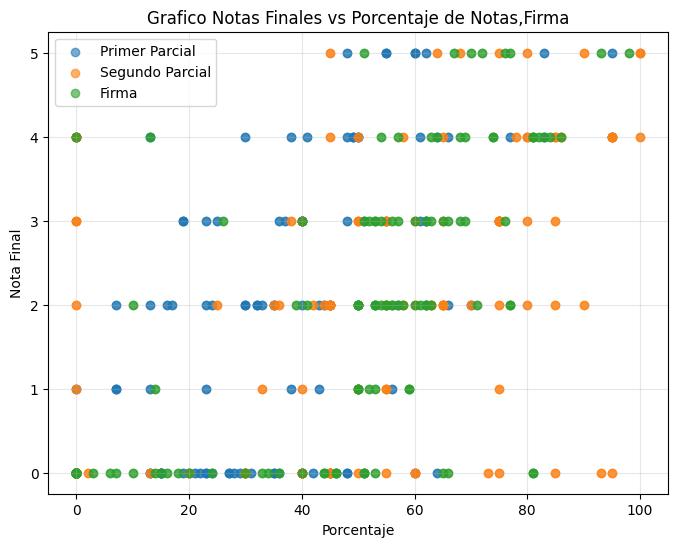

In [56]:
# Visualizar datos

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], y_sal, alpha=0.6, label='Primer Parcial')
plt.scatter(X[:,1], y, alpha=0.6, label='Segundo Parcial')
plt.scatter(X[:,2], y_sal, alpha=0.6, label='Firma')
plt.xlabel('Porcentaje')
plt.ylabel('Nota Final')
plt.title('Grafico Notas Finales vs Porcentaje de Notas,Firma')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En la escala el 0 indica que el estudiante no llego ni a habilitar el final.

In [57]:
#Entrenamientos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y_sal, test_size=0.2, random_state=42
)
##Standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
##Regresion Lineal, de 0.4 R2 a 0.6 con grado = 4
modeloLin=make_pipeline(
    PolynomialFeatures(degree=4, include_bias=False),
    LinearRegression()
)
modeloLin.fit(X_train, y_train)
##RandomForest, finetuning

param_grid = {
    'n_estimators': [10,50,100,200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt',1.0,2],
}
#200 arboles de decision
modeloF = RandomForestRegressor( random_state=42)

grid_search = GridSearchCV(
    estimator=modeloF,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
#modeloF.fit(X_train, y_train)
grid_search.fit(X_train, y_train)
modeloF=grid_search.best_estimator_
#Neural Networks
#red neuronal de 3 capas, activacion relu para regresion
modeloC = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])
#optimizador tipo adam del descenso del gradiente, funcion de perdida minimos de errores
#cuadrados
## tasa de aprendizaje de 0.005, se obtuvo mejores metricas con 0.001
optimizer = keras.optimizers.Adam(learning_rate=0.001)
modeloC.compile(
    optimizer,
    loss="mse",
    metrics=["mae"]
)

modeloC.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)



Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step - loss: 9.2645 - mae: 2.3272 - val_loss: 11.1093 - val_mae: 2.7248
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.9926 - mae: 2.2824 - val_loss: 10.7945 - val_mae: 2.6810
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8.7594 - mae: 2.2383 - val_loss: 10.4913 - val_mae: 2.6385
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.5298 - mae: 2.1967 - val_loss: 10.1974 - val_mae: 2.5974
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8.3130 - mae: 2.1583 - val_loss: 9.9168 - val_mae: 2.5581
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.0966 - mae: 2.1208 - val_loss: 9.6523 - val_mae: 2.5204
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 7.8968 - mae: 2.0879 - val_loss: 9.3964 - val_mae: 2.4834
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 7.7000 - mae: 2.0575 - val_loss: 9.1540 - val_mae: 2.4490
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.5191 - mae: 2.0320 

In [58]:
# 7. Evaluar el modelo
#Regresion Lineal
y_predL = modeloLin.predict(X_test)

maeL=mean_absolute_error(y_test, y_predL)
mseL = mean_squared_error(y_test, y_predL)
rmseL=np.sqrt(mean_squared_error(y_test, y_predL))
R2L=r2_score(y_test, y_predL)

#RandomForest
y_predF = modeloF.predict(X_test)

maeF=mean_absolute_error(y_test, y_predF)
mseF = mean_squared_error(y_test, y_predF)
rmseF=np.sqrt(mean_squared_error(y_test, y_predF))
R2F=r2_score(y_test, y_predF)

#NeuronalNetwork
y_predC = modeloC.predict(X_test)

maeC=mean_absolute_error(y_test, y_predC)
mseC = mean_squared_error(y_test, y_predC)
rmseC=np.sqrt(mean_squared_error(y_test, y_predC))
R2C=r2_score(y_test, y_predC)
print("Metricas")
data = {'MAE': [maeL,maeF,maeC],'MSE':[mseL,mseF,mseC], 'RMSE': [rmseL,rmseF,rmseC],'R2':[R2L,R2F,R2C]}
df_resultados = pd.DataFrame(data, index=['Regresion Lineal', 'Random Forest', 'Neuronal Network'])
print(df_resultados)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
Metricas
                       MAE       MSE      RMSE        R2
Regresion Lineal  0.804959  1.109290  1.053228  0.601557
Random Forest     0.619306  0.827560  0.909703  0.702751
Neuronal Network  0.907621  1.373915  1.172141  0.506508


In [61]:
##Prueba sintetica
#El estudiante se encuentra antes de la fecha de los finales
#ya con firma y se pregunta que nota tendra si toma el examen final
# teniendo en cuenta su performance en los parciales.
#1P 2P Firma -----Nueva Malla
entrada=np.array([[50, 50, 62]])
entrada=scaler.transform(entrada)
print("Predictor Lineal",modeloLin.predict(entrada))
print("Predictor RandomForest",modeloF.predict(entrada))
print("Predictor Neuronal",modeloC.predict(entrada))
#

Predictor Lineal [4.08369524]
Predictor RandomForest [2.48]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predictor Neuronal [[2.4286146]]


**Qué problema resolvió.**

Un estimador de notas finales en la malla nueva en la materia Mecanica de Solidos, teniendo en cuenta la firma y
la nota de los 2 parciales.

**Qué modelo obtuvo mejores resultados.**

El modelo que obtuvo mejores resultados fue el RandomForest

**Qué aprendió del dataset.**

Hay muchos aplazos en las materias con rama en mecanica, con promedio bajo

**Qué posibles mejoras podrían realizarse.**

Realizar un gridSearch para el randomForest ya que ese fue el regresor con mejor performance.

**Seleccion del modelo**

Se selecciona el Random Forest por tener mejor correlacion R2, menor MSE, RMSE (diferencia entre MAE y RMSE es el menor. 0.208)y MAE(menor error unitario 0.6 aprox). Tambien por que los datos filtrados son pocos, 234 entradas.